In [53]:
import requests
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities
import networkx as nx
import numpy as np
!pip install pingouin
import pingouin as pg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 7.3 MB/s eta 0:00:00


# Project 1: Nike

On Facebook, business pages can "like" other pages, and a directed network could be derived from this liking relationship. Jane collected all the pages liked by Nike and the linking relationships among these pages. This results in two datesets:
- facebook_node_attributes.csv
- facebook_data.csv

The first dataset includes page attributes and the second data contains the edgelist information. We will visualize and explore how centrality attributes, together with other node-level attributes, could be used for spokeperson selection.




## Problem 1.1
Generate a subgraph with nodes that have more than 80,000,000 fan count. Visualize this network with node labels and upload the network graph. Make sure to use kamada_kawai_layout as the layout algorithm.

Tips: You can visualize the whole network first and then generate the subgragh.

Expected output:
- code
- gragh

> 💡 **Hint:** See class notebook **Section 1.3** for building a graph from an edgelist, **Section 1.4** for visualization parameters (including layout algorithms), and **Section 1.6** for filtering nodes by attribute and creating a subgraph.

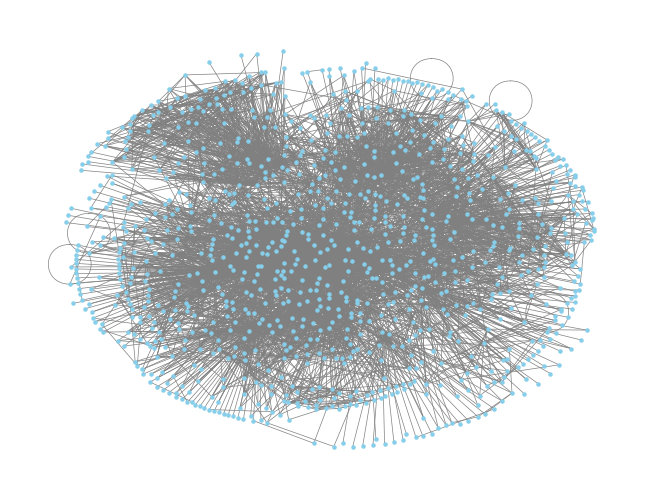

In [4]:
edgelist=pd.read_csv('facebook_data.csv')
G=nx.from_pandas_edgelist(
    edgelist,
    source='username1',
    target='username2',
)

# No need to add create_using=nx.DiGraph() if it is an undirected graph

nx.draw(G, with_labels=False, node_size=5,node_color='skyblue',width=0.5, edge_color='gray',pos= nx.kamada_kawai_layout(G))


In [5]:
# Calculate eigenvector centrality
eigenvector_centrality =  nx.eigenvector_centrality(G)
# Calculate in-degree centrality
in_degree_centrality =  nx.degree_centrality(G)
# Calculate out-degree centrality
out_degree_centrality =  nx.degree_centrality(G)
# Calculate betweenness centrality
betweenness_centrality =  nx.betweenness_centrality(G)
# Calculate closeness centrality
closeness_centrality =  nx.closeness_centrality(G)
# Save node attributes.
nx.set_node_attributes(G, eigenvector_centrality, 'eigenvector_centrality')
nx.set_node_attributes(G, in_degree_centrality, 'in_degree_centrality')
nx.set_node_attributes(G, out_degree_centrality, 'out_degree_centrality')
nx.set_node_attributes(G, betweenness_centrality, 'betweenness_centrality')
nx.set_node_attributes(G, closeness_centrality, 'closeness_centrality')

In [7]:
node_attribute=pd.read_csv('facebook_node_attributes.csv')

for index, row in node_attribute.iterrows():
    node_id = row['username']
    attributes = row.drop(labels=['username', 'Unnamed: 0'], errors='ignore').to_dict()
    nx.set_node_attributes(G, {node_id: attributes})

In [8]:
attributes_list=[]
for node, attributes in G.nodes(data=True):
    attributes_list.append(attributes)

attributes_df=pd.DataFrame(attributes_list)


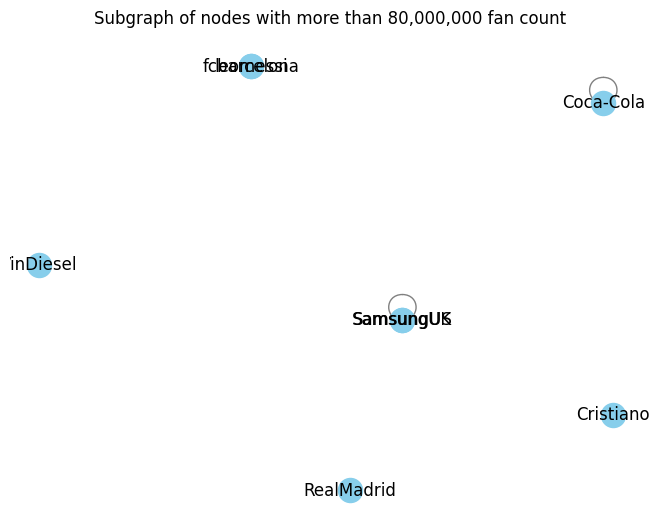

['SamsungUK', 'Coca-Cola', 'fcbarcelona', 'leomessi', 'VinDiesel', 'SamsungUS', 'RealMadrid', 'Cristiano']


In [15]:
selected_nodes = []
for node, data in G.nodes(data=True):
     if data.get('fan_count', 0) > 80_000_000:
        selected_nodes.append(node)

subgraph = G.subgraph(selected_nodes)
pos = nx.kamada_kawai_layout(subgraph)

nx.draw(subgraph, pos, with_labels=True, node_color='skyblue', edge_color='gray')


plt.title("Subgraph of nodes with more than 80,000,000 fan count")
plt.show()
print(list(subgraph.nodes()))


### Your Output — Problem 1.1

```
+------------------------------------------------------------+
| Paste your subgraph visualization here.                    |


I did not found a way to paste the actual image, but it is above, on canvas and here s a list fo the selected nodes.

['SamsungUK', 'Coca-Cola', 'fcbarcelona', 'leomessi', 'VinDiesel', 'SamsungUS', 'RealMadrid', 'Cristiano']


+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 1.1:** Upload the subgraph network visualization.
---

## Problem 1.2
For this subgraph, generate a dataframe to save all attributes of the nodes. Copy the code here. Then, using network centrality measures as support to discuss who Nike should hire as spokesperson if Nike focuses not only on fan count but also network centrality.

Tip: use sort_values(by= "columname", ascending=False) to identify nodes with high centrality measures.

Expected output:
- Code
- Propose 3 spokespeople for Nike. For each spokesperson, discuss their centrality and why you proposed them. Demonstrate your knowledge about different centrality measures in the discussion.

> 💡 **Hint:** See class notebook **Section 1.5** for definitions and calculation of centrality measures, and **Section 1.6** for saving node attributes into a dataframe.

In [19]:
attributes_list=[]
for node, attributes in subgraph.nodes(data=True):
    row = {'username' : node, **attributes}
    attributes_list.append(row)

attributes_df=pd.DataFrame(attributes_list)
attributes_df

,username,eigenvector_centrality,in_degree_centrality,out_degree_centrality,betweenness_centrality,closeness_centrality,name,label,category,post_activity,fan_count,talking_about_count,users_can_post
0,SamsungUK,0.009169,0.007828,0.007828,0.000284,0.325374,1.270000e+14,Samsung,Computer Company,0.22,159992225,12253,yes
1,Coca-Cola,0.032254,0.030333,0.030333,0.009309,0.373129,4.079631e+10,Coca-Cola,Food & Beverage,0.00,107873884,7025,yes
2,fcbarcelona,0.049205,0.030333,0.030333,0.007515,0.375735,1.970000e+11,FC Barcelona,Sports Team,0.21,102653035,924723,no
3,leomessi,0.050201,0.022505,0.022505,0.004072,0.375184,1.760000e+14,Leo Messi,Athlete,0.01,89957459,680636,no
4,VinDiesel,0.005742,0.003914,0.003914,0.000056,0.301031,8.956227e+10,Vin Diesel,Artist,0.01,99132429,47288,no
5,SamsungUS,0.011788,0.006849,0.006849,0.001279,0.335302,7.224957e+09,Samsung,Electronics Company,0.43,159997828,87893,yes
6,RealMadrid,0.021029,0.012720,0.012720,0.001328,0.340326,1.903472e+10,Real Madrid C.F.,Sports Team,0.09,109425487,904634,no
7,Cristiano,0.052994,0.048924,0.048924,0.046602,0.402997,8.122120e+10,Cristiano Ronaldo,Athlete,0.03,122672469,688102,no


In [25]:
keep_categories = [
    "Athlete",
    "Sports Team"
]


filtered_df = attributes_df[attributes_df["category"].isin(keep_categories)].copy()
filtered_df

filtered_df = filtered_df.sort_values(
    by=["eigenvector_centrality"],
    ascending=[False],
)
filtered_df





,username,eigenvector_centrality,in_degree_centrality,out_degree_centrality,betweenness_centrality,closeness_centrality,name,label,category,post_activity,fan_count,talking_about_count,users_can_post
7,Cristiano,0.052994,0.048924,0.048924,0.046602,0.402997,8.122120e+10,Cristiano Ronaldo,Athlete,0.03,122672469,688102,no
3,leomessi,0.050201,0.022505,0.022505,0.004072,0.375184,1.760000e+14,Leo Messi,Athlete,0.01,89957459,680636,no
2,fcbarcelona,0.049205,0.030333,0.030333,0.007515,0.375735,1.970000e+11,FC Barcelona,Sports Team,0.21,102653035,924723,no
6,RealMadrid,0.021029,0.012720,0.012720,0.001328,0.340326,1.903472e+10,Real Madrid C.F.,Sports Team,0.09,109425487,904634,no


### Your Output — Problem 1.2

```
+------------------------------------------------------------+
Propose 3 spokespeople for Nike.   

To propose 3 spokeperson for Nike, first I did a qualitative analysis on the categories of the accounts.
Given the type of products Nike sells I decided to prioritize accounts that have a category of "athelete" or "sportsteam" becase they are the ones that align the most with the type of product Nike sells and those are the companies that makes the most sense that would talk about nike.

The I did a quantitative analysis based on the centrality measures and what we are trying to achieve. If I already chose an account, I would not consider him again for the othar capaigns.


The spoke person i would choode would depend on the type of "problem" or "result" Nike is tryong to focus on:

If we want to reach new audiences I would go with cristiano ronaldo because he has the highest betweness centrality, so he works as a connector for new groups.
He also has the highest eigenvector_centrality, so that gives him a lot of credibility because he is connected to influencers.


If we want a campaing just to have a lot of visibility I wuld go with FCBarcelona because they have a high in_degree_centrality. This could be to get the conversation going of a new product launch or something we want people to talk about.

If we want to reach a particular group fast I would go with leo Messi because he has a high closeness centrality, meaning he can get information to his network realitvely fast.





+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 1.2:** Submit your spokesperson proposals with centrality-based justifications.
---

## Problem 1.3

For the whole network (no filtering), perform community detection and plot the network by allowing nodes in different communities to be colored differently. Please note that community detection is only applicable to undirected network, and you will need to use ```G = G.to_undirected()``` to turn the network to an undirected network before you perform community detection.

Expected output:
- Code.
- A network gragh to show communities (no labels are needed for nodes).

> 💡 **Hint:** See class notebook **Section 1.8** for community detection, mapping nodes to community IDs, and coloring nodes by community.

In [26]:
G = G.to_undirected()

communities = greedy_modularity_communities(G)

# Display number of communities
print(f"Detected {len(communities)} communities.")


Detected 8 communities.


In [27]:
# Map each node to a community ID
node_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i
        G.nodes[node]['community'] = i


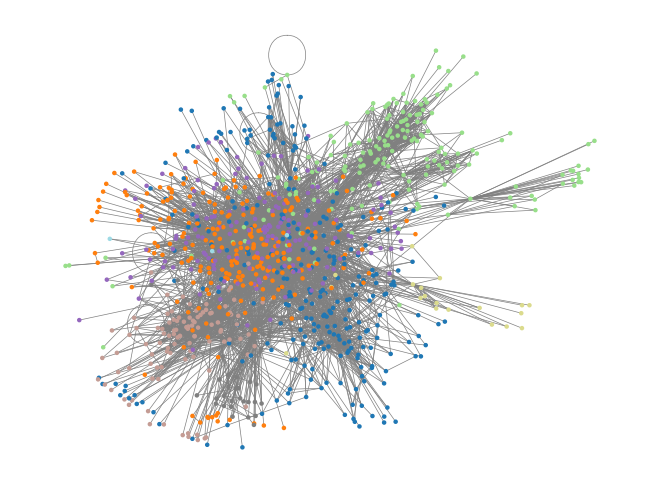

In [31]:
# Visualization

colors = []
for n in G.nodes():
    colors.append(node_community[n])

pos = nx.spring_layout(G, seed=42)

#nx.draw(G, pos, node_color=colors, with_labels=False)

nx.draw(
    G,
    pos,
    node_color=colors,
    cmap=plt.cm.tab20,
    with_labels=False,
    node_size=5,
    width=0.5,
    edge_color="gray",
)


### Your Output — Problem 1.3

```
+------------------------------------------------------------+
Image is above, and on canvas (i was not able to pase an image)                                                      |
+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 1.3:** Upload the community-colored network graph.
---

# Project 2: Bright Kite
Brightkite was a location-based social networking website. Users were able to "check in" at places by using text messaging or one of the mobile applications and they were able to see who is nearby and who has been there before. The source of the data is [here](https://snap.stanford.edu/data/loc-brightkite.html).

## Problem 2.1
Generate a network using connections on BrightKite and display the network. Note that this is an undirected network and we need to remove ```create_using=nx.DiGraph()``` when generating this network. Upload your network graph below.

Expected Output:
- Code
- Network Plot

> 💡 **Hint:** See class notebook **Section 1.3** for building a graph from an edgelist and **Section 1.4** for visualization parameters.

In [32]:
edgelist=pd.read_csv('brightkite_edgelist.csv')
edgelist

,node1,node2
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5
...,...,...
1575,121,61
1576,121,82
1577,121,88
1578,121,120


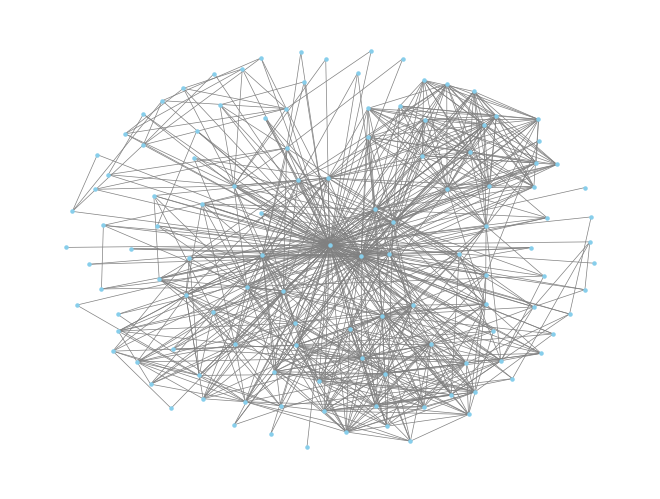

In [34]:
G=nx.from_pandas_edgelist(
        edgelist,
    source='node1',
    target='node2',
)
                             # No need to add create_using=nx.DiGraph() if it is an undirected graph

nx.draw(G, with_labels=False, node_size=5,node_color='skyblue',width=0.5, edge_color='gray',pos= nx.kamada_kawai_layout(G))

### Your Output — Problem 2.1

```
+------------------------------------------------------------+
i was not able to paste the image but it is above and on canvas.
+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 2.1:** Upload the BrightKite network visualization.
---

## Problem 2.2
Generate centrality measures and add these network attributes to the network. Note that for undirected network, in-degree and out-degree are the same. We generate degree centrality by using ```degree_centrality = nx.degree_centrality(G)```.

Then, import brightkite_checkins.csv and add external attributes of "checkins" to the network as a new network attribute. We further include node name as an additional feature by using the following code:
```
for node in G.nodes():
    G.nodes[node]['name'] = node
```
Finally, save all node-level attributes into a dataframe and print this dataframe.

Expected output:
- Code
- Answer this question: how many nodes are there in this network?


> 💡 **Hint:** See class notebook **Section 1.5** for calculating centrality measures and adding them as node attributes, and **Section 2.2** for attaching external attributes from a dataframe to network nodes.

In [35]:
# Calculate eigenvector centrality
eigenvector_centrality = nx.eigenvector_centrality(G)
# Calculate in-degree centrality
degree_centrality = nx.degree_centrality(G)
# Calculate out-degree centrality
betweenness_centrality = nx.betweenness_centrality(G)
# Calculate closeness centrality
closeness_centrality = nx.closeness_centrality(G)
# Save node attributes.
nx.set_node_attributes(G, eigenvector_centrality, "eigenvector_centrality")
nx.set_node_attributes(G, degree_centrality, "degree_centrality")
nx.set_node_attributes(G, betweenness_centrality, "betweenness_centrality")
nx.set_node_attributes(G, closeness_centrality, "closeness_centrality")



Import the checkin data

In [36]:
node_attribute=pd.read_csv("brightkite_checkins.csv")

for index, row in node_attribute.iterrows():
    node_id = int(row['node'])
    attributes = row.drop(['node']).to_dict()  # Convert row to dictionary excluding node_id
    nx.set_node_attributes(G, {node_id: attributes})

Save node attributes into a dataframe

In [37]:
attributes_list=[]
for node, attributes in G.nodes(data=True):
    attributes_list.append(attributes)

attributes_df=pd.DataFrame(attributes_list)
attributes_df

,eigenvector_centrality,degree_centrality,betweenness_centrality,closeness_centrality,checkins
0,0.365188,1.000000,0.610739,1.000000,2100
1,0.110019,0.166667,0.000833,0.545455,1210
2,0.084494,0.166667,0.007907,0.545455,2100
3,0.110094,0.158333,0.003335,0.542986,1807
4,0.089532,0.133333,0.000306,0.535714,779
...,...,...,...,...,...
116,0.040560,0.058333,0.000000,0.515021,43
117,0.017976,0.016667,0.000000,0.504202,2
118,0.031783,0.058333,0.000460,0.515021,7
119,0.046360,0.066667,0.000481,0.517241,4


### Your Output — Problem 2.2

```
+------------------------------------------------------------+
| How many nodes are there in this network?                  |
There are 121 nodes. There is no room in canvas to submit this answer.                                                      |
+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 2.2:** Submit your code and answer the node count question.
---

## Problem 2.3
The platform wants to install a recommendation system to recommend friends. Which users are likely to be friends? Perform an edge prediction based on Jaccard similarity coefficient and print the top 20 edges.

Expected Output:
- Code
- Top 20 edges

> 💡 **Hint:** See class notebook **Section 2.3** for Jaccard-based edge prediction and extracting the top predictions.

In [40]:
G_undirected = G.to_undirected()

preds = nx.jaccard_coefficient(G_undirected)

preds_list = list(preds)
preds_df = pd.DataFrame(preds_list, columns=['node_u', 'node_v', 'score'])
preds_df = preds_df.sort_values('score', ascending=False).reset_index(drop=True)
pd.set_option('display.max_rows', None)


# Display top 100
preds_df.head(20)

,node_u,node_v,score
0,107,122,1.000000
1,96,107,1.000000
2,96,122,1.000000
3,73,122,1.000000
4,89,90,1.000000
5,111,119,1.000000
6,73,107,1.000000
7,73,96,1.000000
8,1,11,0.952381
9,57,78,0.750000


### Your Output — Problem 2.3

```
+------------------------------------------------------------+
| Paste your top 20 predicted edges here.                    |
node_u	node_v	score
0	107	122	1.0
1	96	107	1.0
2	96	122	1.0
3	73	122	1.0
4	89	90	1.0
5	111	119	1.0
6	73	107	1.0
7	73	96	1.0
8	1	11	0.9523809523809523
9	57	78	0.75
10	63	84	0.75
11	19	78	0.75
12	93	97	0.7333333333333333
13	56	97	0.7333333333333333
14	39	89	0.6666666666666666
15	62	89	0.6666666666666666
16	39	90	0.6666666666666666
17	78	89	0.6666666666666666
18	84	111	0.6666666666666666
19	78	90


There is no place in canvas to submit this answer.
+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 2.3:** Submit your code and top 20 edge predictions.
---

## Problem 2.4
Generate a subgraph for nodes with eigenvector centrality higher than 0.1. Plot the network and upload the network graph.
Expected output:
- code
- gragh

> 💡 **Hint:** See class notebook **Section 1.6** for filtering nodes by a threshold attribute value and generating a subgraph.

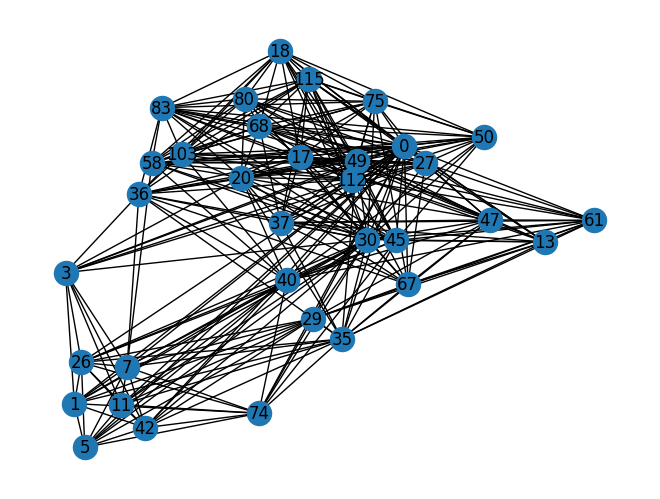

In [41]:
selected_nodes = []
for node, data in G.nodes(data=True):
    if data.get("eigenvector_centrality") > 0.1:
        selected_nodes.append(node)


pos = nx.spring_layout(G)
subgraph = G.subgraph(selected_nodes)
nx.draw(subgraph, pos, with_labels=True)

### Your Output — Problem 2.4

```
+------------------------------------------------------------+
| Paste your subgraph visualization here.       

I was not able to paste the image here, but it is above. but it is in canvas
+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 2.4:** Upload the subgraph of nodes with eigenvector centrality > 0.1.
---

## Problem 2.5
Run a linear regression to explore how centrality measures affect the outcome of log(checkins+1).
Expected output:
- code
- regression results
- interpretation

> 💡 **Hint:** See class notebook **Section 1.7** for setting up node attributes as model inputs and running a linear regression.

In [42]:
print(attributes_df)

     eigenvector_centrality  degree_centrality  betweenness_centrality  \
0                  0.365188           1.000000                0.610739   
1                  0.110019           0.166667                0.000833   
2                  0.084494           0.166667                0.007907   
3                  0.110094           0.158333                0.003335   
4                  0.089532           0.133333                0.000306   
5                  0.100508           0.150000                0.000420   
6                  0.036613           0.041667                0.000082   
7                  0.127951           0.200000                0.002440   
8                  0.022927           0.025000                0.000035   
9                  0.087830           0.125000                0.000200   
10                 0.038302           0.083333                0.001751   
11                 0.114069           0.175000                0.000956   
12                 0.094688           

In [54]:
# Complete the code for Problem 2.5
import pandas as pd
import numpy as np
import pingouin as pg

pred_cols = [
    "eigenvector_centrality",
    "degree_centrality",
    "betweenness_centrality",
    "closeness_centrality",
]
df_model = attributes_df[pred_cols + ["checkins"]].dropna().copy()
df_model["log_checkins"] = np.log1p(df_model["checkins"].astype(float))

# Same pattern as Week 4 §1.7: predictors = all columns except outcome helpers
result = pg.linear_regression(
    df_model.drop(columns=["checkins", "log_checkins"]),
    df_model["log_checkins"],
)
print(result.round(4))

                    names      coef        se       T    pval      r2  adj_r2  \
0               Intercept  196.4836   65.9716  2.9783  0.0035  0.3945  0.3736   
1  eigenvector_centrality   19.6483   15.4937  1.2681  0.2073  0.3945  0.3736   
2       degree_centrality  110.4850   40.4934  2.7285  0.0074  0.3945  0.3736   
3  betweenness_centrality  131.3800   47.1915  2.7840  0.0063  0.3945  0.3736   
4    closeness_centrality -386.4788  132.1642 -2.9242  0.0042  0.3945  0.3736   

      CI2.5    CI97.5  
0   65.8186  327.1486  
1  -11.0389   50.3354  
2   30.2828  190.6873  
3   37.9112  224.8488  
4 -648.2467 -124.7110  


### Your Output — Problem 2.5

```
+------------------------------------------------------------+
| Interpret the regression results here.                     |
| - Which centrality measures are significant predictors     |
|   of check-ins?  

Using a significance level of 0.05 degree_centrality betweenness_centrality and closeness_centrality are significant predictors of check_in                                          |
| - What does the R² tell you about the model?               |

We have an r2 0.3945 which means that 39% of the variation in log(checkins) is explained by our model.
+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 2.5:** Submit your  regression results and interpretation. (keep your code here)
---

# Problem 3

In our class exercise, we used function 'search_tweets_by_topic' from package itom6219 to retrieve tweets based on topic.
In this homework exercise, I designed a workflow to get you familiar with how to build a query to retrieve posts from X.
Take a moment to read this page: https://docs.x.com/x-api/posts/search/integrate/build-a-query


## Problem 3.1 Start with a basic query
- Create a query that includes the keyword of both "SMU" and "Football". Note that the AND operator is a space in X API.
- Set `include_mentions=False`
- `max_results=10`
- Save the output to `tweets_dict`

> 💡 **Hint:** See class notebook **Section 2.1** for the query syntax table and examples of combining keywords with Boolean operators.

In [ ]:
import os
!pip3 install --upgrade git+https://github.com/tantantan12/itom6219.git
from itom6219 import  user_info, user_tweets, user_tweets_all, search_tweets_by_topic  ,extract_user_mention_edges
from google.colab import userdata

In [61]:

os.environ["BEARER_TOKEN"] =userdata.get('BEARER_TOKEN')
tweets_dict = search_tweets_by_topic(
    topic="SMU Football", # Fill in your query here
    include_mentions=False,
    max_results=10
)

use `tweets_df = pd.DataFrame(tweets_dict['data'])` to turn the dictionary into a dataframe.

Use the code `pd.set_option('display.max_colwidth', None)` to allow full display of pandas content

In [62]:
print(tweets_dict)

{'data': [{'entities': {'mentions': [{'start': 0, 'end': 14, 'username': 'ordinarybritt', 'id': '30302060'}]}, 'edit_history_tweet_ids': ['2039754641538257318'], 'text': '@ordinarybritt This is proof that in the age of NIL/transfer portal, money talks and bullshit walks. A blue blood program in the past might not remain so.\n\nIf Jaida Civil goes, the Lady Vols have no roster, and for all intents and purposes, are where SMU football was in 1987 and 1988.', 'created_at': '2026-04-02T17:19:38.000Z', 'public_metrics': {'retweet_count': 0, 'reply_count': 1, 'like_count': 1, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 184}, 'id': '2039754641538257318', 'author_id': '3493352534'}, {'edit_history_tweet_ids': ['2039753701313954021'], 'text': 'UNlV was NIL before NIL! SMU football. Give em their wins back! https://t.co/8gg0E1PSNa', 'created_at': '2026-04-02T17:15:53.000Z', 'public_metrics': {'retweet_count': 0, 'reply_count': 0, 'like_count': 2, 'quote_count': 0, 'bookmark_count'

In [63]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
tweets_df = pd.DataFrame(tweets_dict['data'])
tweets_df

,entities,edit_history_tweet_ids,text,created_at,public_metrics,id,author_id
0,"{'mentions': [{'start': 0, 'end': 14, 'username': 'ordinarybritt', 'id': '30302060'}]}",[2039754641538257318],"@ordinarybritt This is proof that in the age of NIL/transfer portal, money talks and bullshit walks. A blue blood program in the past might not remain so.\n\nIf Jaida Civil goes, the Lady Vols have no roster, and for all intents and purposes, are where SMU football was in 1987 and 1988.",2026-04-02T17:19:38.000Z,"{'retweet_count': 0, 'reply_count': 1, 'like_count': 1, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 184}",2039754641538257318,3493352534
1,NaN,[2039753701313954021],UNlV was NIL before NIL! SMU football. Give em their wins back! https://t.co/8gg0E1PSNa,2026-04-02T17:15:53.000Z,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 2, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 122}",2039753701313954021,1841663038396760067
2,NaN,[2039743455690183121],Full SMU Spring Football Practice Report: https://t.co/NhU8oK2Zmh https://t.co/SRRWx2c30x,2026-04-02T16:35:11.000Z,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 38}",2039743455690183121,2031803388082683904
3,NaN,[2039743454205374908],Former SMU OL Hayden Howerton takes you inside SMU Football spring practice to give you the latest scoop👀\n\n#RunWithUs https://t.co/JV2noiySkr,2026-04-02T16:35:10.000Z,"{'retweet_count': 1, 'reply_count': 1, 'like_count': 9, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 184}",2039743454205374908,2031803388082683904
4,NaN,"[2039719463273033878, 2039734350653128779]","Road Rage today, everything you need to know about ACC football thus far. Canes are the team to beat but are they invincible? Cards are my dark-horse team and why. SMU with Jennings, Clemson, UVA, Pitt? NCAA Tourney, Stories in and outside of sports, American celebration. Still",2026-04-02T15:59:00.000Z,"{'retweet_count': 2, 'reply_count': 2, 'like_count': 3, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 2001}",2039734350653128779,415664857
5,NaN,"[2039719463273033878, 2039734350653128779]","Road Rage today, everything you need to know about ACC football thus far. Cane's are the team to beat but are they invincible? Cards are my dark-horse team and why. SMU with Jennings, Clemson, UVA, Pitt? NCAA Tourney, Stories in and outside of sports, American celebration.",2026-04-02T14:59:50.000Z,"{'retweet_count': 1, 'reply_count': 0, 'like_count': 3, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 701}",2039719463273033878,415664857
6,NaN,[2039553430222495846],Underated recruiting classes .\nNCAA College Football 2026.\n\nVirginia Tech \nIllinois \nBYU\nN.C State\nTexas Tech \nNorth Carolina \nIowa\nSouth Carolina \nSMU,2026-04-02T04:00:05.000Z,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 1, 'impression_count': 170}",2039553430222495846,1752082679900553216
7,"{'mentions': [{'start': 0, 'end': 12, 'username': 'appcenter52', 'id': '4649159843'}, {'start': 13, 'end': 21, 'username': 'ch52nyk', 'id': '333515263'}, {'start': 22, 'end': 34, 'username': 'BDunnsports', 'id': '262471486'}]}",[2039525269682245899],@appcenter52 @ch52nyk @BDunnsports i’d say if you’re making a football comparison then a school like BYU or SMU (pre ACC) is a better comparison. non power school that clearly has the financial resources to be competitive on a national level. coastal baseball competes financially with USC,2026-04-02T02:08:11.000Z,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 38}",2039525269682245899,1307360649027215360
8,"{'mentions': [{'start': 0, 'end': 10, 'username': 'tedstone3', 'id': '20152622'}, {'start': 11, 'end': 24, 'username': 'SEisbergWCIV', 'id': '59366117'}]}",[2039484892870738085],@tedstone3 @SEisbergWCIV Charleston has plenty of money lol. He’s saying i

## Problem 3.3 Broaden for better coverage

Broaden coverage by using OR to include additional sports topics (e.g., `(SMU Football) OR (SMU Basketball)`).

> 💡 **Hint:** See class notebook **Section 2.1** for examples of using Boolean OR to combine multiple topic queries.

In [64]:
tweets_dict = search_tweets_by_topic(
    topic="(SMU Football) OR (SMU Basketball)", # Fill in your query here
    include_mentions=False,
    max_results=10
)
tweets_df = pd.DataFrame(tweets_dict['data'])
tweets_df

,id,text,public_metrics,edit_history_tweet_ids,author_id,entities,created_at
0,2040491748091195884,@dylanxciv @tominsalem @CasualHoya Duke football isn’t awful. Louisville is good. Smu is good. It would only work if football stayed decent. Or they wouldn’t come. Wake Forrest and NC state wouldn’t be excluded,"{'retweet_count': 0, 'reply_count': 2, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 15}",[2040491748091195884],540422308,"{'mentions': [{'start': 0, 'end': 10, 'username': 'dylanxciv', 'id': '1845648846212218882'}, {'start': 11, 'end': 22, 'username': 'tominsalem', 'id': '250094384'}, {'start': 23, 'end': 34, 'username': 'CasualHoya', 'id': '26624619'}]}",2026-04-04T18:08:37.000Z
1,2040453050859466817,Don't miss the inside scoop from SMU football practice with Run Peruna Run!\n\nJoin today and support NIL efforts for the Mustangs! #RunWithUs https://t.co/tQaE8akzQ2,"{'retweet_count': 1, 'reply_count': 1, 'like_count': 7, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 94}",[2040453050859466817],2031803388082683904,NaN,2026-04-04T15:34:51.000Z
2,2040444441903911133,"SMU DB Breakdown: 2025 Review, Spring Football Outlook https://t.co/ZsSsV0jIEy","{'retweet_count': 0, 'reply_count': 0, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 3}",[2040444441903911133],1695129127882211328,NaN,2026-04-04T15:00:39.000Z
3,2040290069773189494,@clifferrell @TheDeacMachine Dickert seems pretty happy with the funding he’s getting. I like to see it get to about 20 million that’s what SMU spent when they went to the college football playoffs two years ago.,"{'retweet_count': 0, 'reply_count': 1, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 18}",[2040290069773189494],1805627954115805184,"{'mentions': [{'start': 0, 'end': 12, 'username': 'clifferrell', 'id': '366746332'}, {'start': 13, 'end': 28, 'username': 'TheDeacMachine', 'id': '1260990015309582336'}]}",2026-04-04T04:47:14.000Z
4,2040267974934659352,"It was a pleasure to chat with and lock in with the Director of Player Personnel Coach Mann @Thamannjr !! From one of the top programs in the ACC, the team even shocked the college football world last year, Southern Methodist University Mustangs (SMU) 🐎💙❤️ !! \n\nGot to show him https://t.co/el0WBli7pK","{'retweet_count': 0, 'reply_count': 0, 'like_count': 2, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 63}",[2040267974934659352],1993005649496600576,"{'mentions': [{'start': 92, 'end': 102, 'username': 'Thamannjr', 'id': '198999077'}]}",2026-04-04T03:19:26.000Z
5,2040240646758261232,@kj7_enthusiast @PeteThamel Still in your head speaks a lot about SMU football,"{'retweet_count': 0, 'reply_count': 1, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 11}",[2040240646758261232],1863809062304980992,"{'mentions': [{'start': 0, 'end': 15, 'username': 'kj7_enthusiast', 'id': '1985199006004207616'}, {'start': 16, 'end': 27, 'username': 'PeteThamel', 'id': '68441962'}]}",2026-04-04T01:30:50.000Z
6,2040238793408565578,Per @BillyEmbody \nIn-depth look at SMU spring football practice Friday ahead of the weekend off for the Mustangs.#RunWithUs https://t.co/B08xWe2GTb \nhttps://t.co/7lobc30GGf,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 1, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 38}",[2040238793408565578],1470881109915414531,"{'mentions': [{'start': 4, 'end': 16, 'username': 'BillyEmbody', 'id': '67782321'}]}",2026-04-04T01:23:28.000Z
7,2040234156832022601,In-depth look at SMU spring football practice Friday ahead of the weekend off for the Mustangs.\n\n#RunWithUs https://t.co/jY873kCm0X,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 12, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 2417}",[2040234156832022601],67782321,NaN,2026-04-04T01:05:03.000Z
8,2040234022819749918,"Practice Report: SMU standouts of Week 2, new developments in spring football👀\n\nhttps://t.co/f9aICB8M1i

## Problem 3.4 Add emotion filters

Now add emotion keywords (e.g., `(happy OR happiness OR excited OR elated)`) to your query from 3.3. Use grouping with parentheses so that the query matches tweets about SMU sports AND containing an emotion keyword.

> 💡 **Hint:** See class notebook **Section 2.1** for examples of grouping with parentheses to combine topic and emotion filters in a single query.

In [66]:
tweets_dict = search_tweets_by_topic(
    topic="(SMU Football) (happy OR excited OR favorite) OR (SMU Basketball) (happy OR excited OR favorite)", # Fill in your query here
    include_mentions=False,
    max_results=10
)
tweets_df = pd.DataFrame(tweets_dict['data'])
tweets_df

,text,edit_history_tweet_ids,id,entities,author_id,created_at,public_metrics
0,@clifferrell @TheDeacMachine Dickert seems pretty happy with the funding he’s getting. I like to see it get to about 20 million that’s what SMU spent when they went to the college football playoffs two years ago.,[2040290069773189494],2040290069773189494,"{'mentions': [{'start': 0, 'end': 12, 'username': 'clifferrell', 'id': '366746332'}, {'start': 13, 'end': 28, 'username': 'TheDeacMachine', 'id': '1260990015309582336'}]}",1805627954115805184,2026-04-04T04:47:14.000Z,"{'retweet_count': 0, 'reply_count': 1, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 18}"
1,"Excited to be attending @SMUFB camp this summer! Looking forward to learning from @rhettlashlee, @CoachRobLikens, and @bryanfilker and putting in the work 💪🔥 #SMU #Football #Grind https://t.co/eDacfD1IaO",[2040161531241922965],2040161531241922965,"{'mentions': [{'start': 24, 'end': 30, 'username': 'SMUFB', 'id': '312737543'}, {'start': 82, 'end': 95, 'username': 'rhettlashlee', 'id': '157531194'}, {'start': 97, 'end': 112, 'username': 'CoachRobLikens', 'id': '464848122'}, {'start': 118, 'end': 130, 'username': 'bryanfilker', 'id': '390209284'}]}",1445129431127834637,2026-04-03T20:16:28.000Z,"{'retweet_count': 1, 'reply_count': 0, 'like_count': 9, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 480}"


## Problem 3.5 Export tweets to CSV file (only the last file)

This question is a practice of the function `to_csv` which can export a pandas dataframe as a csv file. It will be listed in the file section of Google Colab for you to download and upload to Canvas.

In [69]:
tweets_df.to_csv("Collectedtweets_robles_eduardo.csv")

> 📤 **Submit to Canvas — Problem 3.5:** Submit a csv file with your collected tweet(s).